In [4]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l
n = 10000
a = torch.ones([n])
b = torch.ones([n])

In [5]:
class Timer:  
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

In [6]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.07723 sec'

In [7]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00000 sec'

In [8]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

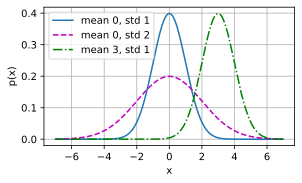

In [11]:

x = np.arange(-7, 7, 0.01)
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
         ylabel='p(x)', figsize=(4.5, 2.5),
         legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

线性回归从0开始实现

In [13]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [15]:
def synthetic_data(w, b, num_examples):  # @save
    """生成y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [17]:
ture_w = torch.tensor([2, -3.4])
ture_b = 4.2
features, labels = synthetic_data(ture_w, ture_b, 1000)
print('features:', features[0], '\nlabel:', labels[0])

features: tensor([ 0.4638, -1.0671]) 
label: tensor([8.7678])


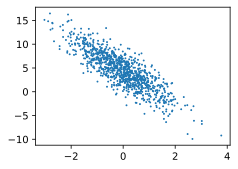

In [18]:
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(),
                labels.detach().numpy(), 1)